In [1]:
%run neural_simulation_functions.ipynb

Parameters.

In [3]:
num_neurons = 10
rate = 10 
time = 1000
num_samples = 10
t0 = 200

In [4]:
# Simulation control parameters
g_values = [3, 5, 7, 9]

# Network parameters
N_E = 1000
gamma = 0.25
N_I = round(gamma * N_E)
N = N_E + N_I
epsilon = 0.1
C_E = epsilon * N_E
C_ext = C_E

# Neuron parameters
tau = 20  * ms
theta = 20  * mV
V_r = 10  * mV
tau_rp = 2  * ms

# Synapse parameters
J = 0.1  * mV
D = 1.5  * ms

# Simulation settings
dt = 0.1  * ms
g = 7 # g is a good control for manipulating the firing rate
nu_ext_over_nu_thr = 2
# t_range = [1000, 1200]
# rate_range = [0, 200]
# rate_tick_step = 50

Generating spike trains, then counting the spikes.

In [6]:
raw_spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)
print(raw_spike_train)

WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 100. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[{0: array([ 48.9,  77.9, 126.7, 170.4, 254.1, 311.2, 349. , 400.8, 694.1,
       818.2, 920. , 985.7]) * msecond, 1: array([0.055 , 0.0657, 0.1437, 0.1816, 0.3595, 0.4268, 0.4635, 0.4971,
       0.5473, 0.7051, 0.8476, 0.9544]) * second, 2: array([ 10.1,  13.7, 135.1, 520.1, 753.4, 838.9, 875.1, 908. , 973.6]) * msecond, 3: array([0.0525, 0.0923, 0.2198, 0.4982, 0.5788, 0.6219, 0.684 , 0.6878,
       0.7791, 0.7949, 0.9359, 0.9653, 0.9746]) * second, 4: array([  6.5,  80.6,  90.6, 300.5, 305.2, 390.6, 399.6, 447. , 494.8,
       542.3, 629.5, 796.2, 881.9, 963.6]) * msecond, 5: array([0.1032, 0.1284, 0.1521, 0.1906, 0.4187, 0.5701, 0.6436, 0.668 ,
       0.7568, 0.8278, 0.9414, 0.9528]) * second, 6: array([0.0103, 0.0758, 0.2792, 0.327 , 0.4585, 0.592 , 0.6582, 0.6763,
       0.8889, 0.8931, 0.901 , 0.9598]) * second, 7: array([0.3257, 0.3541, 0.3772, 0.4524, 0.5852, 0.5929, 0.6691, 0.6735,
       0.7101, 0.8271, 0.8402, 0.9748]) * second, 8: array([0.1014, 0.3357, 0.3779, 0.4763, 0.5

In [7]:
save_spike_trains(raw_spike_train, "spike_trains.json")
loaded_spike_trains = load_spike_trains("spike_trains.json")
print(loaded_spike_trains)

Spike trains saved to spike_trains.json
[{0: array([ 48.9,  77.9, 126.7, 170.4, 254.1, 311.2, 349. , 400.8, 694.1,
       818.2, 920. , 985.7]) * msecond, 1: array([0.055 , 0.0657, 0.1437, 0.1816, 0.3595, 0.4268, 0.4635, 0.4971,
       0.5473, 0.7051, 0.8476, 0.9544]) * second, 2: array([ 10.1,  13.7, 135.1, 520.1, 753.4, 838.9, 875.1, 908. , 973.6]) * msecond, 3: array([0.0525, 0.0923, 0.2198, 0.4982, 0.5788, 0.6219, 0.684 , 0.6878,
       0.7791, 0.7949, 0.9359, 0.9653, 0.9746]) * second, 4: array([  6.5,  80.6,  90.6, 300.5, 305.2, 390.6, 399.6, 447. , 494.8,
       542.3, 629.5, 796.2, 881.9, 963.6]) * msecond, 5: array([0.1032, 0.1284, 0.1521, 0.1906, 0.4187, 0.5701, 0.6436, 0.668 ,
       0.7568, 0.8278, 0.9414, 0.9528]) * second, 6: array([0.0103, 0.0758, 0.2792, 0.327 , 0.4585, 0.592 , 0.6582, 0.6763,
       0.8889, 0.8931, 0.901 , 0.9598]) * second, 7: array([0.3257, 0.3541, 0.3772, 0.4524, 0.5852, 0.5929, 0.6691, 0.6735,
       0.7101, 0.8271, 0.8402, 0.9748]) * second, 8: ar

In [8]:
spike_train = standardize_units(raw_spike_train)
print(spike_train)

[{0: array([0.0489, 0.0779, 0.1267, 0.1704, 0.2541, 0.3112, 0.349 , 0.4008,
       0.6941, 0.8182, 0.92  , 0.9857]), 1: array([0.055 , 0.0657, 0.1437, 0.1816, 0.3595, 0.4268, 0.4635, 0.4971,
       0.5473, 0.7051, 0.8476, 0.9544]), 2: array([0.0101, 0.0137, 0.1351, 0.5201, 0.7534, 0.8389, 0.8751, 0.908 ,
       0.9736]), 3: array([0.0525, 0.0923, 0.2198, 0.4982, 0.5788, 0.6219, 0.684 , 0.6878,
       0.7791, 0.7949, 0.9359, 0.9653, 0.9746]), 4: array([0.0065, 0.0806, 0.0906, 0.3005, 0.3052, 0.3906, 0.3996, 0.447 ,
       0.4948, 0.5423, 0.6295, 0.7962, 0.8819, 0.9636]), 5: array([0.1032, 0.1284, 0.1521, 0.1906, 0.4187, 0.5701, 0.6436, 0.668 ,
       0.7568, 0.8278, 0.9414, 0.9528]), 6: array([0.0103, 0.0758, 0.2792, 0.327 , 0.4585, 0.592 , 0.6582, 0.6763,
       0.8889, 0.8931, 0.901 , 0.9598]), 7: array([0.3257, 0.3541, 0.3772, 0.4524, 0.5852, 0.5929, 0.6691, 0.6735,
       0.7101, 0.8271, 0.8402, 0.9748]), 8: array([0.1014, 0.3357, 0.3779, 0.4763, 0.5203, 0.6256, 0.7303, 0.8856,
    

In [9]:
binary_spikes = spikes_to_binary(spike_train, num_neurons, time)
print(binary_spikes[0][0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [10]:
spike_count = count_spikes(binary_spikes)
count = np.array(spike_count)
print(count.shape)

(10, 10, 1000)


In [11]:
print(spike_count[0]) # first sample
print(count[0])

[array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,
        2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
        2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
        2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
        2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  

Getting spike trains from excitatory and inhibitory neurons, then counting the spikes.

In [13]:
# results = sim(params["g"], params["nu_ext_over_nu_thr"], params["t_range"][1] * ms, ax_spikes, ax_rates, params["rate_tick_step"], num_neurons, num_samples)
results = sim(g, nu_ext_over_nu_thr, time, num_neurons, num_samples)

raw_excitatory_spike_trains = results['excitatory']['spike_trains']
raw_inhibitory_spike_trains = results['inhibitory']['spike_trains']
print(raw_excitatory_spike_trains)

[{0: array([0.0145, 0.0412, 0.0939, 0.1313, 0.1559, 0.1798, 0.1984, 0.2195,
       0.2516, 0.2806, 0.303 , 0.3282, 0.3533, 0.3854, 0.4095, 0.424 ,
       0.456 , 0.4818, 0.5102, 0.5216, 0.5486, 0.5669, 0.5951, 0.6078,
       0.6337, 0.6592, 0.6815, 0.7004, 0.7281, 0.7518, 0.7871, 0.8043,
       0.8398, 0.8546, 0.8866, 0.9018, 0.9287, 0.959 , 0.9831, 0.9949]) * second, 1: array([0.0146, 0.0256, 0.0401, 0.0537, 0.0698, 0.0892, 0.1065, 0.1223,
       0.1441, 0.1579, 0.1784, 0.1958, 0.2097, 0.2284, 0.2443, 0.2609,
       0.2731, 0.2911, 0.3044, 0.3199, 0.3399, 0.3537, 0.3641, 0.3825,
       0.3981, 0.4107, 0.4306, 0.4437, 0.465 , 0.4803, 0.496 , 0.5106,
       0.5227, 0.5359, 0.5525, 0.5678, 0.5887, 0.5961, 0.6121, 0.6242,
       0.636 , 0.6441, 0.6581, 0.6778, 0.692 , 0.7047, 0.7155, 0.7281,
       0.7431, 0.7569, 0.7731, 0.7882, 0.8029, 0.8242, 0.8465, 0.8569,
       0.8716, 0.8871, 0.9001, 0.9129, 0.9319, 0.9477, 0.9631, 0.9796,
       0.9963]) * second, 2: array([0.0218, 0.0387, 0.0483

In [14]:
save_spike_trains(raw_excitatory_spike_trains, "spike_trains_ex.json")
loaded_spike_trains_ex = load_spike_trains("spike_trains_ex.json")

save_spike_trains(raw_inhibitory_spike_trains, "spike_trains_in.json")
loaded_spike_trains_in = load_spike_trains("spike_trains_in.json")

Spike trains saved to spike_trains_ex.json
Spike trains saved to spike_trains_in.json


In [15]:
# result = vary_g(sim, g_values)

In [16]:
excitatory_spike_trains = standardize_units(raw_excitatory_spike_trains)
inhibitory_spike_trains = standardize_units(raw_inhibitory_spike_trains)

print(excitatory_spike_trains[0])
print(inhibitory_spike_trains[0])

{0: array([0.0145, 0.0412, 0.0939, 0.1313, 0.1559, 0.1798, 0.1984, 0.2195,
       0.2516, 0.2806, 0.303 , 0.3282, 0.3533, 0.3854, 0.4095, 0.424 ,
       0.456 , 0.4818, 0.5102, 0.5216, 0.5486, 0.5669, 0.5951, 0.6078,
       0.6337, 0.6592, 0.6815, 0.7004, 0.7281, 0.7518, 0.7871, 0.8043,
       0.8398, 0.8546, 0.8866, 0.9018, 0.9287, 0.959 , 0.9831, 0.9949]), 1: array([0.0146, 0.0256, 0.0401, 0.0537, 0.0698, 0.0892, 0.1065, 0.1223,
       0.1441, 0.1579, 0.1784, 0.1958, 0.2097, 0.2284, 0.2443, 0.2609,
       0.2731, 0.2911, 0.3044, 0.3199, 0.3399, 0.3537, 0.3641, 0.3825,
       0.3981, 0.4107, 0.4306, 0.4437, 0.465 , 0.4803, 0.496 , 0.5106,
       0.5227, 0.5359, 0.5525, 0.5678, 0.5887, 0.5961, 0.6121, 0.6242,
       0.636 , 0.6441, 0.6581, 0.6778, 0.692 , 0.7047, 0.7155, 0.7281,
       0.7431, 0.7569, 0.7731, 0.7882, 0.8029, 0.8242, 0.8465, 0.8569,
       0.8716, 0.8871, 0.9001, 0.9129, 0.9319, 0.9477, 0.9631, 0.9796,
       0.9963]), 2: array([0.0218, 0.0387, 0.0483, 0.0671, 0.0827, 0

In [17]:
binary_ex_spikes = spikes_to_binary(excitatory_spike_trains, num_neurons, time)
binary_in_spikes = spikes_to_binary(inhibitory_spike_trains, num_neurons, time)

print(binary_ex_spikes[0][0]) # first sample of first neuron

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.

In [18]:
spike_count_ex = count_spikes(binary_ex_spikes)
print(spike_count_ex[0])
count_ex = np.array(spike_count_ex)
print(count_ex[0])
print(count_ex.shape)

spike_count_in = count_spikes(binary_in_spikes)
count_in = np.array(spike_count_in)
print(count_in.shape)

[array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
        2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
        2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
        2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
        2.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,
        4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  5.,
        5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,
        5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  6.,  

Theoretical and Empirical stats of raw counts.

In [20]:
theoretical_means = calculate_theoretical_mean(rate, time)
print(theoretical_means)
print(theoretical_means.shape)

theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

theoretical_lower_bound, theoretical_upper_bound = confidence_intervals(theoretical_means, theoretical_std_dev, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.   0.01 0.02 ... 9.97 9.98 9.99]
 [0.   0.01 0.02 ... 9.97 9.98 9.99]]
(2, 1000)
[[0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]
 [0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]]
(2, 1000)


In [21]:
empirical_mean = empirical_means(count)
print(empirical_mean)
print(empirical_mean.shape)

empirical_std_dev = std_dev_empirical_mean(empirical_mean, num_samples, count)
print(empirical_std_dev)
print(empirical_std_dev.shape)

empirical_lower_bound, empirical_upper_bound = confidence_intervals(empirical_mean, empirical_std_dev, num_samples, confidence_level=0.95)
# print(empirical_lower_bound)
# print(empirical_upper_bound)

[[ 0.   0.   0.  ... 11.1 11.1 11.1]
 [ 0.   0.1  0.1 ... 10.7 10.7 10.7]
 [ 0.   0.   0.  ...  8.3  8.3  8.3]
 ...
 [ 0.   0.1  0.1 ... 11.9 11.9 11.9]
 [ 0.1  0.1  0.1 ... 11.3 11.3 11.3]
 [ 0.   0.1  0.1 ...  8.3  8.3  8.3]]
(10, 1000)
[[0.         0.         0.         ... 3.78447119 3.78447119 3.78447119]
 [0.         0.31622777 0.31622777 ... 2.26323269 2.26323269 2.26323269]
 [0.         0.         0.         ... 2.66874919 2.66874919 2.66874919]
 ...
 [0.         0.31622777 0.31622777 ... 2.92308817 2.92308817 2.92308817]
 [0.31622777 0.31622777 0.31622777 ... 3.88873016 3.88873016 3.88873016]
 [0.         0.31622777 0.31622777 ... 2.26323269 2.26323269 2.26323269]]
(10, 1000)


Theoretical and Empirical stats of excitatory counts.

In [23]:
empirical_mean_ex = empirical_means(count_ex)
print(empirical_mean_ex)
# print(empirical_mean_ex.shape)

[[ 0.   0.   0.  ... 38.2 38.4 38.4]
 [ 0.   0.   0.  ... 65.3 65.4 65.4]
 [ 0.   0.   0.  ... 62.9 62.9 63. ]
 ...
 [ 0.   0.   0.  ... 57.6 57.7 57.7]
 [ 0.   0.   0.  ... 49.4 49.4 49.4]
 [ 0.   0.   0.  ... 45.7 46.  46.1]]


In [24]:
empirical_std_dev_ex = std_dev_empirical_mean(empirical_mean_ex, num_samples, count_ex)
print(empirical_std_dev_ex)
print(empirical_std_dev_ex.shape)

[[0.         0.         0.         ... 1.93218357 1.95505044 1.95505044]
 [0.         0.         0.         ... 1.33749351 1.42984071 1.42984071]
 [0.         0.         0.         ... 2.07899548 2.07899548 2.10818511]
 ...
 [0.         0.         0.         ... 1.71269768 1.82878223 1.82878223]
 [0.         0.         0.         ... 1.71269768 1.71269768 1.71269768]
 [0.         0.         0.         ... 1.33749351 1.15470054 1.197219  ]]
(10, 1000)


In [25]:
empirical_lower_bound_ex, empirical_upper_bound_ex = confidence_intervals(empirical_mean_ex, empirical_std_dev_ex, num_samples, confidence_level=0.95)

Theoretical and Empirical stats of inhibitory counts.

In [27]:
empirical_mean_in = empirical_means(count_in)
print(empirical_mean_in)
print(empirical_mean_in.shape)

[[ 0.   0.   0.  ... 87.8 87.8 87.9]
 [ 0.   0.   0.  ... 80.6 80.7 80.7]
 [ 0.   0.   0.  ... 34.  34.1 34.1]
 ...
 [ 0.   0.   0.  ... 78.  78.  78. ]
 [ 0.   0.   0.  ... 66.2 66.2 66.2]
 [ 0.   0.   0.  ... 39.1 39.1 39.3]]
(10, 1000)


In [28]:
empirical_std_dev_in = std_dev_empirical_mean(empirical_mean_in, num_samples, count_in)
print(empirical_std_dev_in)
print(empirical_std_dev_in.shape)

[[0.         0.         0.         ... 1.22927259 1.22927259 1.44913767]
 [0.         0.         0.         ... 1.17378779 1.33749351 1.33749351]
 [0.         0.         0.         ... 1.24721913 1.28668394 1.28668394]
 ...
 [0.         0.         0.         ... 2.21108319 2.21108319 2.21108319]
 [0.         0.         0.         ... 1.03279556 1.03279556 1.03279556]
 [0.         0.         0.         ... 1.37032032 1.37032032 1.15950181]]
(10, 1000)


In [29]:
empirical_lower_bound_in, empirical_upper_bound_in = confidence_intervals(empirical_mean_in, empirical_std_dev_in, num_samples, confidence_level=0.95)

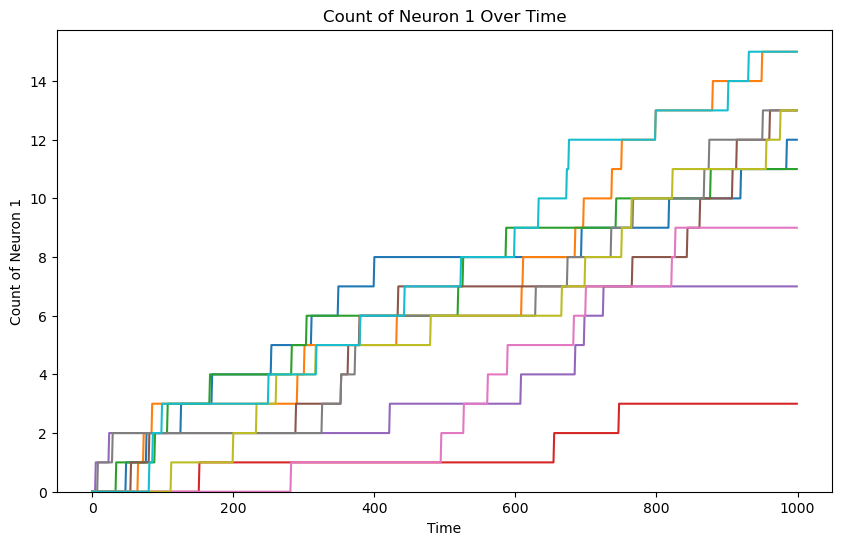

In [30]:
plot_count_neuron1_vs_time(count, num_samples)

Plots of raw counts, excitatory counts, and inhibitory counts centered and standardized.

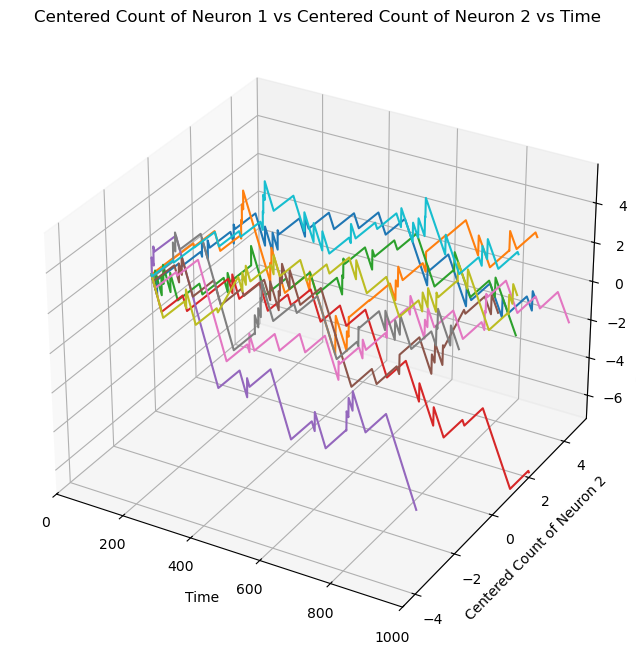

In [32]:
plot_centered_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_11824\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_11824\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


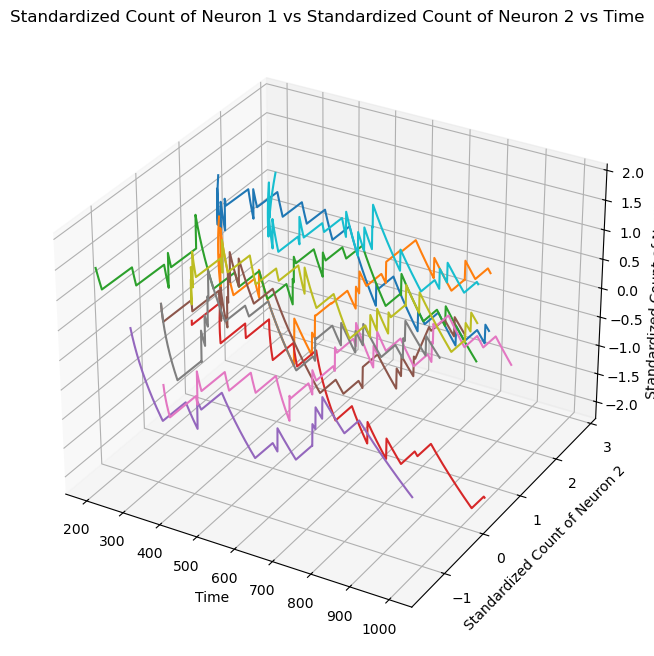

In [33]:
plot_standardized_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev, t0)

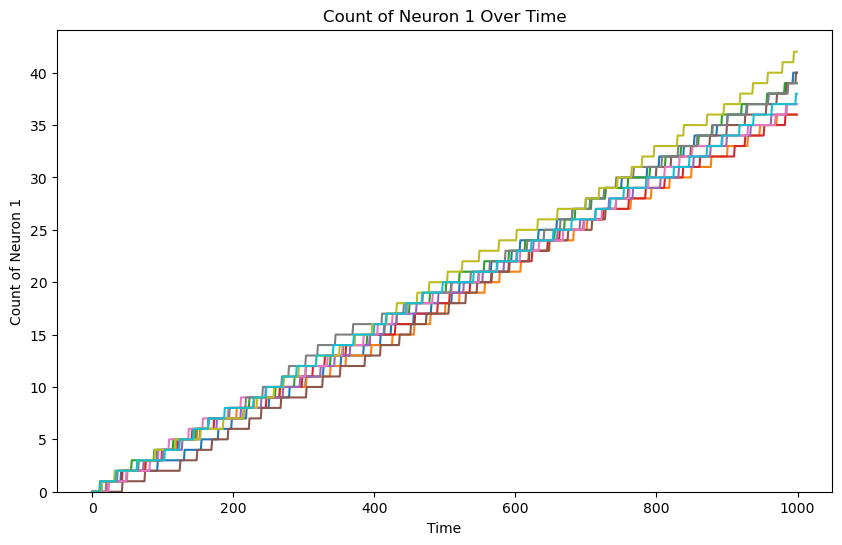

In [34]:
plot_count_neuron1_vs_time(count_ex, num_samples)

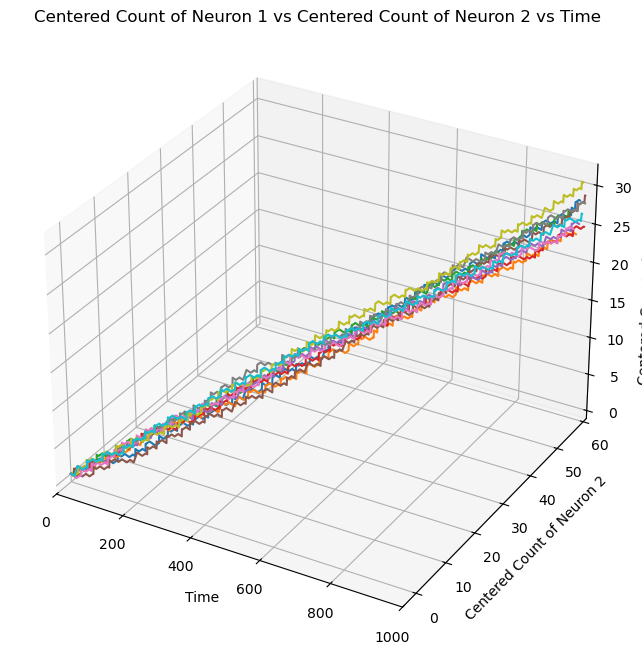

In [35]:
plot_centered_staircase_3d(count_ex, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_11824\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_11824\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


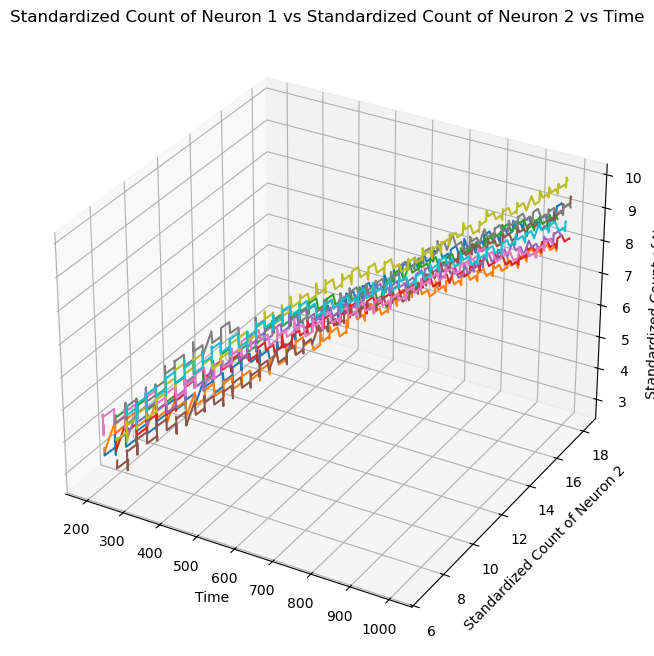

In [36]:
plot_standardized_staircase_3d(count_ex, num_samples, theoretical_means, theoretical_std_dev, t0)

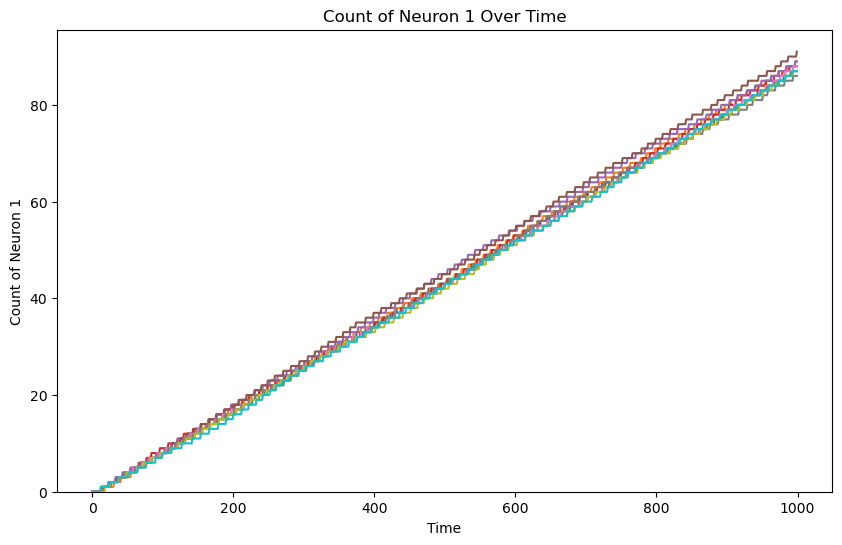

In [37]:
plot_count_neuron1_vs_time(count_in, num_samples)

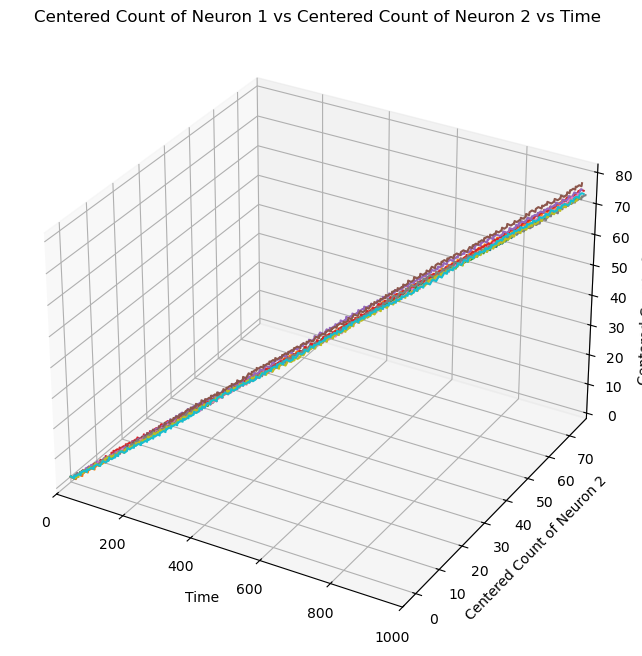

In [38]:
plot_centered_staircase_3d(count_in, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_11824\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_11824\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


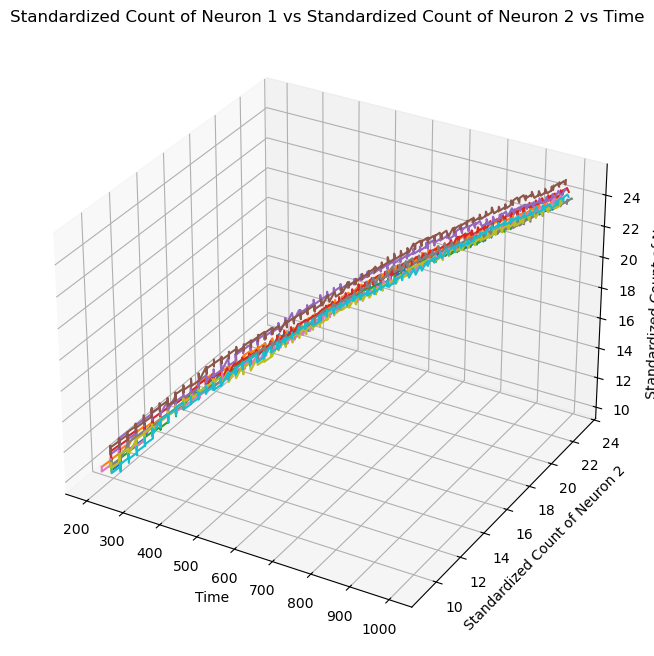

In [39]:
plot_standardized_staircase_3d(count_in, num_samples, theoretical_means, theoretical_std_dev, t0)